In [1]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
with open("../tracker_stubs/ball_detections.pkl", 'rb') as f:
    ball_detections = pickle.load(f)

len(ball_detections)

214

In [3]:
ball_position = [x.get(1, []) for x in ball_detections]
# ball_poistion
# # convert the list into pandas dataframe
df_ball_positions = pd.DataFrame(ball_position, columns=["x1", "y1", "x2", "y2"])
# interpolate the missing values
df_ball_positions = df_ball_positions.interpolate()
df_ball_positions = df_ball_positions.bfill()

In [4]:
df_ball_positions["mid_y"] = (df_ball_positions["y1"] + df_ball_positions["y2"]) / 2
# df_ball_positions["mid_x"] = (df_ball_positions["x1"] + df_ball_positions["x2"]) / 2

# "For each frame, calculate the average mid_y over the current and previous 4 frames.
# The key is to detect a change in the ball's motion.
df_ball_positions['mid_y_rolling_mean'] = df_ball_positions['mid_y'].rolling(window=5, min_periods=1, center=False).mean()

In [5]:
df_ball_positions

,x1,y1,x2,y2,mid_y,mid_y_rolling_mean
0,895.445251,618.047607,912.230347,635.460388,626.753998,626.753998
1,895.445251,618.047607,912.230347,635.460388,626.753998,626.753998
2,873.914246,638.284424,895.667908,659.140503,648.712463,634.073486
3,860.090027,645.889343,881.661865,670.257507,658.073425,640.073471
4,847.579468,659.635213,867.032471,681.292399,670.463806,646.151538
...,...,...,...,...,...,...
209,1185.065552,248.473297,1198.981934,265.607117,257.040207,279.742468
210,1185.115845,233.993408,1195.525635,244.392792,239.193100,267.704311
211,1184.236450,226.549393,1196.433105,241.980331,234.264862,256.508173
212,1180.803955,214.329208,1193.790527,231.511368,222.920288,244.870786


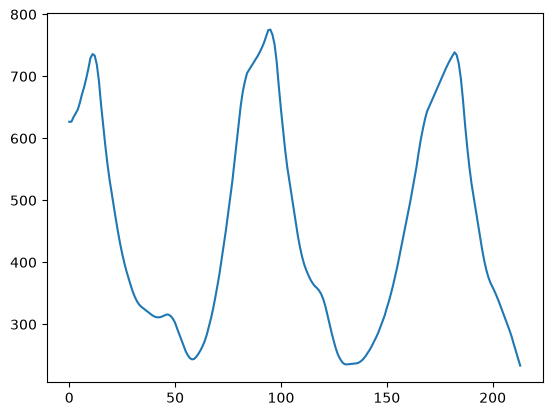

In [6]:
plt.plot(df_ball_positions["mid_y_rolling_mean"])

In [7]:
df_ball_positions['delta_y'] = df_ball_positions['mid_y_rolling_mean'].diff()

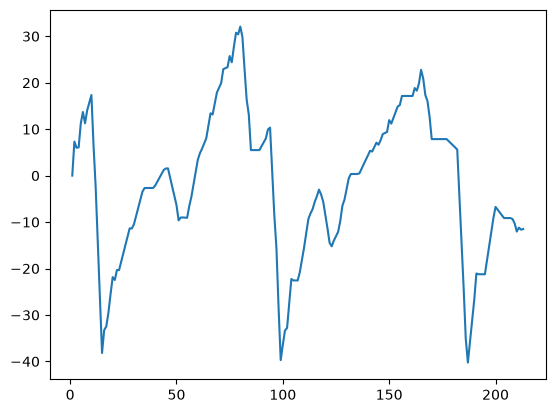

In [8]:
plt.plot(df_ball_positions["delta_y"])

In [9]:
df_ball_positions['ball_hit']=0


In [10]:
len(df_ball_positions)

214

##### Find a frame where the ball changes vertical direction, then check whether that direction change remains consistent for enough frames. If it does, mark that frame as a ball hit.

In [11]:
df_ball_positions['ball_hit']=0

In [17]:
minimum_change_frames_for_hit = 25
for i in range(1, len(df_ball_positions) - int(minimum_change_frames_for_hit * 1.2)):
    negative_position_change = df_ball_positions['delta_y'].iloc[i] > 0  and df_ball_positions["delta_y"].iloc[i+1] < 0
    positive_position_change = df_ball_positions["delta_y"].iloc[i] < 0 and df_ball_positions["delta_y"].iloc[i+1] > 0 

    # if any chane happens to the ball direction
    if negative_position_change or positive_position_change:
        # We're going to count how many future frames continue in the same direction.
        change_count = 0
        for change_frame in range(i+1, i+int(minimum_change_frames_for_hit*1.2)+1):
            negative_position_change_following_frame = df_ball_positions['delta_y'].iloc[i] >0 and df_ball_positions['delta_y'].iloc[change_frame] <0
            positive_position_change_following_frame = df_ball_positions['delta_y'].iloc[i] <0 and df_ball_positions['delta_y'].iloc[change_frame] >0

            if negative_position_change and negative_position_change_following_frame:
                change_count+=1
            elif positive_position_change and positive_position_change_following_frame:
                change_count+=1

        if change_count > minimum_change_frames_for_hit - 1:
            # df_ball_positions["ball_hit"].iloc[i] = 1
            df_ball_positions.loc[df_ball_positions.index[i], "ball_hit"] = 1

frame_nums_with_ball_hits = df_ball_positions[df_ball_positions["ball_hit"] == 1].index.tolist()
frame_nums_with_ball_hits



[11, 58, 95, 131, 182]

In [18]:
# frame_nums_with_ball_hits
df_ball_positions[df_ball_positions['ball_hit']==1]

,x1,y1,x2,y2,mid_y,mid_y_rolling_mean,delta_y,ball_hit
11,776.865967,717.329956,796.806519,738.393127,727.861542,735.918103,6.523395,1
58,925.881409,240.971042,939.039478,253.989072,247.480057,243.406099,-1.957849,1
95,624.777130,748.891968,642.157227,766.698242,757.795105,775.403400,0.871759,1
131,716.963562,229.095024,729.239868,242.786255,235.940639,235.241690,-0.557162,1
182,1294.891235,739.127197,1314.160156,760.564819,749.846008,738.733578,5.602832,1
